<h1><center>EE69210: Machine Learning for Signal Processing Laboratory</center></h1>
<h2><center>Experiment-9: Kernel Density Estimation </center></h2>
<h3><center>Anirvan Krishna | 21EE38002</center></h3>

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Data Generation

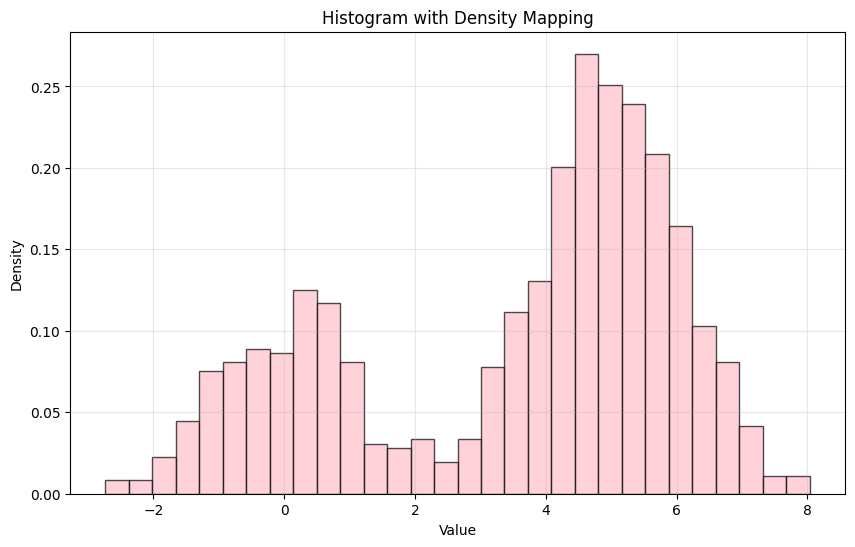

In [32]:
# Define the function provided
def make_data(N, f=0.3, rseed=101):
    rand = np.random.RandomState(rseed)
    x = rand.randn(N)
    x[int(f * N):] += 5
    return x

# 1. Generate the data
x = make_data(1000)

# 2. Plot the histogram of density mappings
plt.figure(figsize=(10, 6))
plt.hist(x, bins=30, density=True, alpha=0.7, color='pink', edgecolor='black')
plt.title('Histogram with Density Mapping')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.savefig('density_histogram.png')
plt.show()

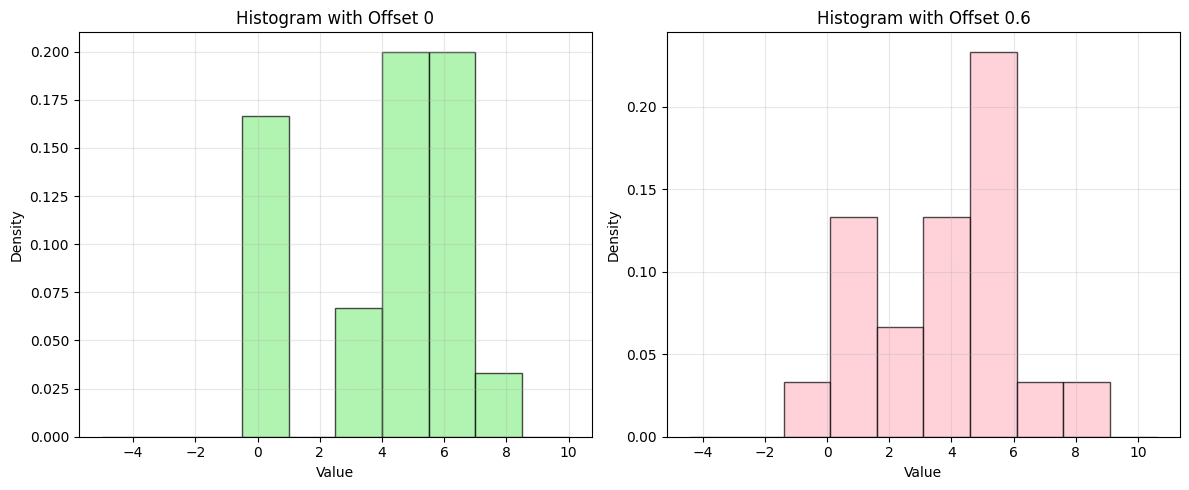

In [21]:
# 3. Create 20 random data points, use 10 equally spaced bins with different offsets
x_small = make_data(20)
bins = np.linspace(-5, 10, 11)  # 10 equally spaced bins from -5 to 10

plt.figure(figsize=(12, 5))

# Plot with offset 0
plt.subplot(1, 2, 1)
plt.hist(x_small, bins=bins, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Histogram with Offset 0')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)

# Plot with offset 0.6
plt.subplot(1, 2, 2)
plt.hist(x_small, bins=bins + 0.6, density=True, alpha=0.7, color='pink', edgecolor='black')
plt.title('Histogram with Offset 0.6')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

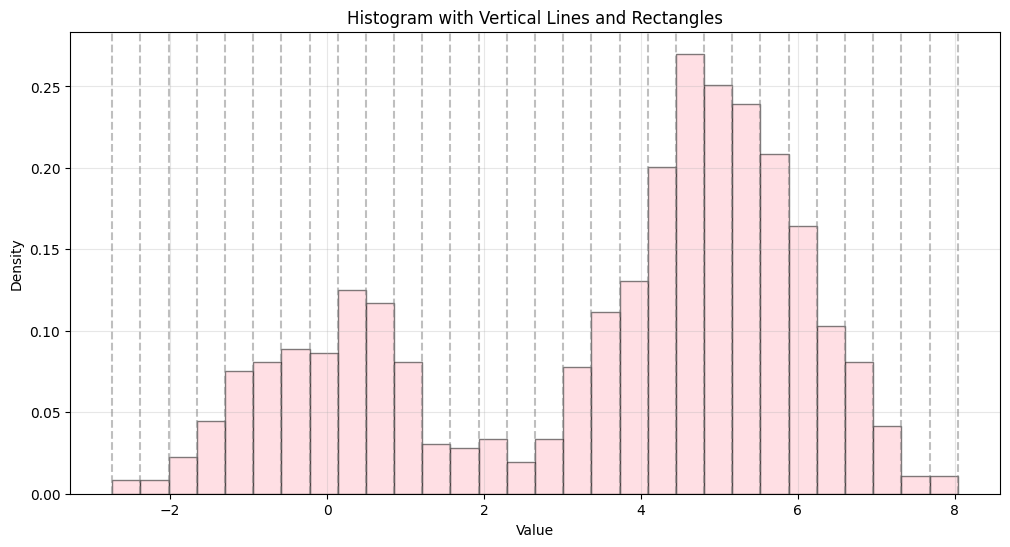

<Figure size 1200x600 with 0 Axes>

In [22]:
# 4. Represent histogram using vertical lines and rectangles
plt.figure(figsize=(12, 6))

# Calculate histogram data
hist_counts, bin_edges = np.histogram(x, bins=30, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Plot rectangles
for i in range(len(hist_counts)):
    plt.bar(bin_centers[i], hist_counts[i], width=bin_width, alpha=0.5, color='pink', edgecolor='black')

# Plot vertical lines at bin edges
for edge in bin_edges:
    plt.axvline(edge, color='gray', linestyle='--', alpha=0.5)

plt.title('Histogram with Vertical Lines and Rectangles')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

# 5. Combine kernel density estimate with vertical lines for individual data points
plt.figure(figsize=(12, 6))

# Generate smaller dataset for clearer visualization
x_medium = make_data(100)

# Kernel Density Estimation

In [36]:
def custom_kde(data_points, x_grid, bandwidth=0.5):

    n_samples = len(data_points)
    n_grid = len(x_grid)
    
    # Initialize the output array
    kde_values = np.zeros(n_grid)
    
    for point in data_points:
        
        kernel = np.exp(-0.5 * ((x_grid - point) / bandwidth)**2)
        kernel = kernel / (bandwidth * np.sqrt(2 * np.pi))
        kde_values += kernel
    
    kde_values /= n_samples
    
    return kde_values

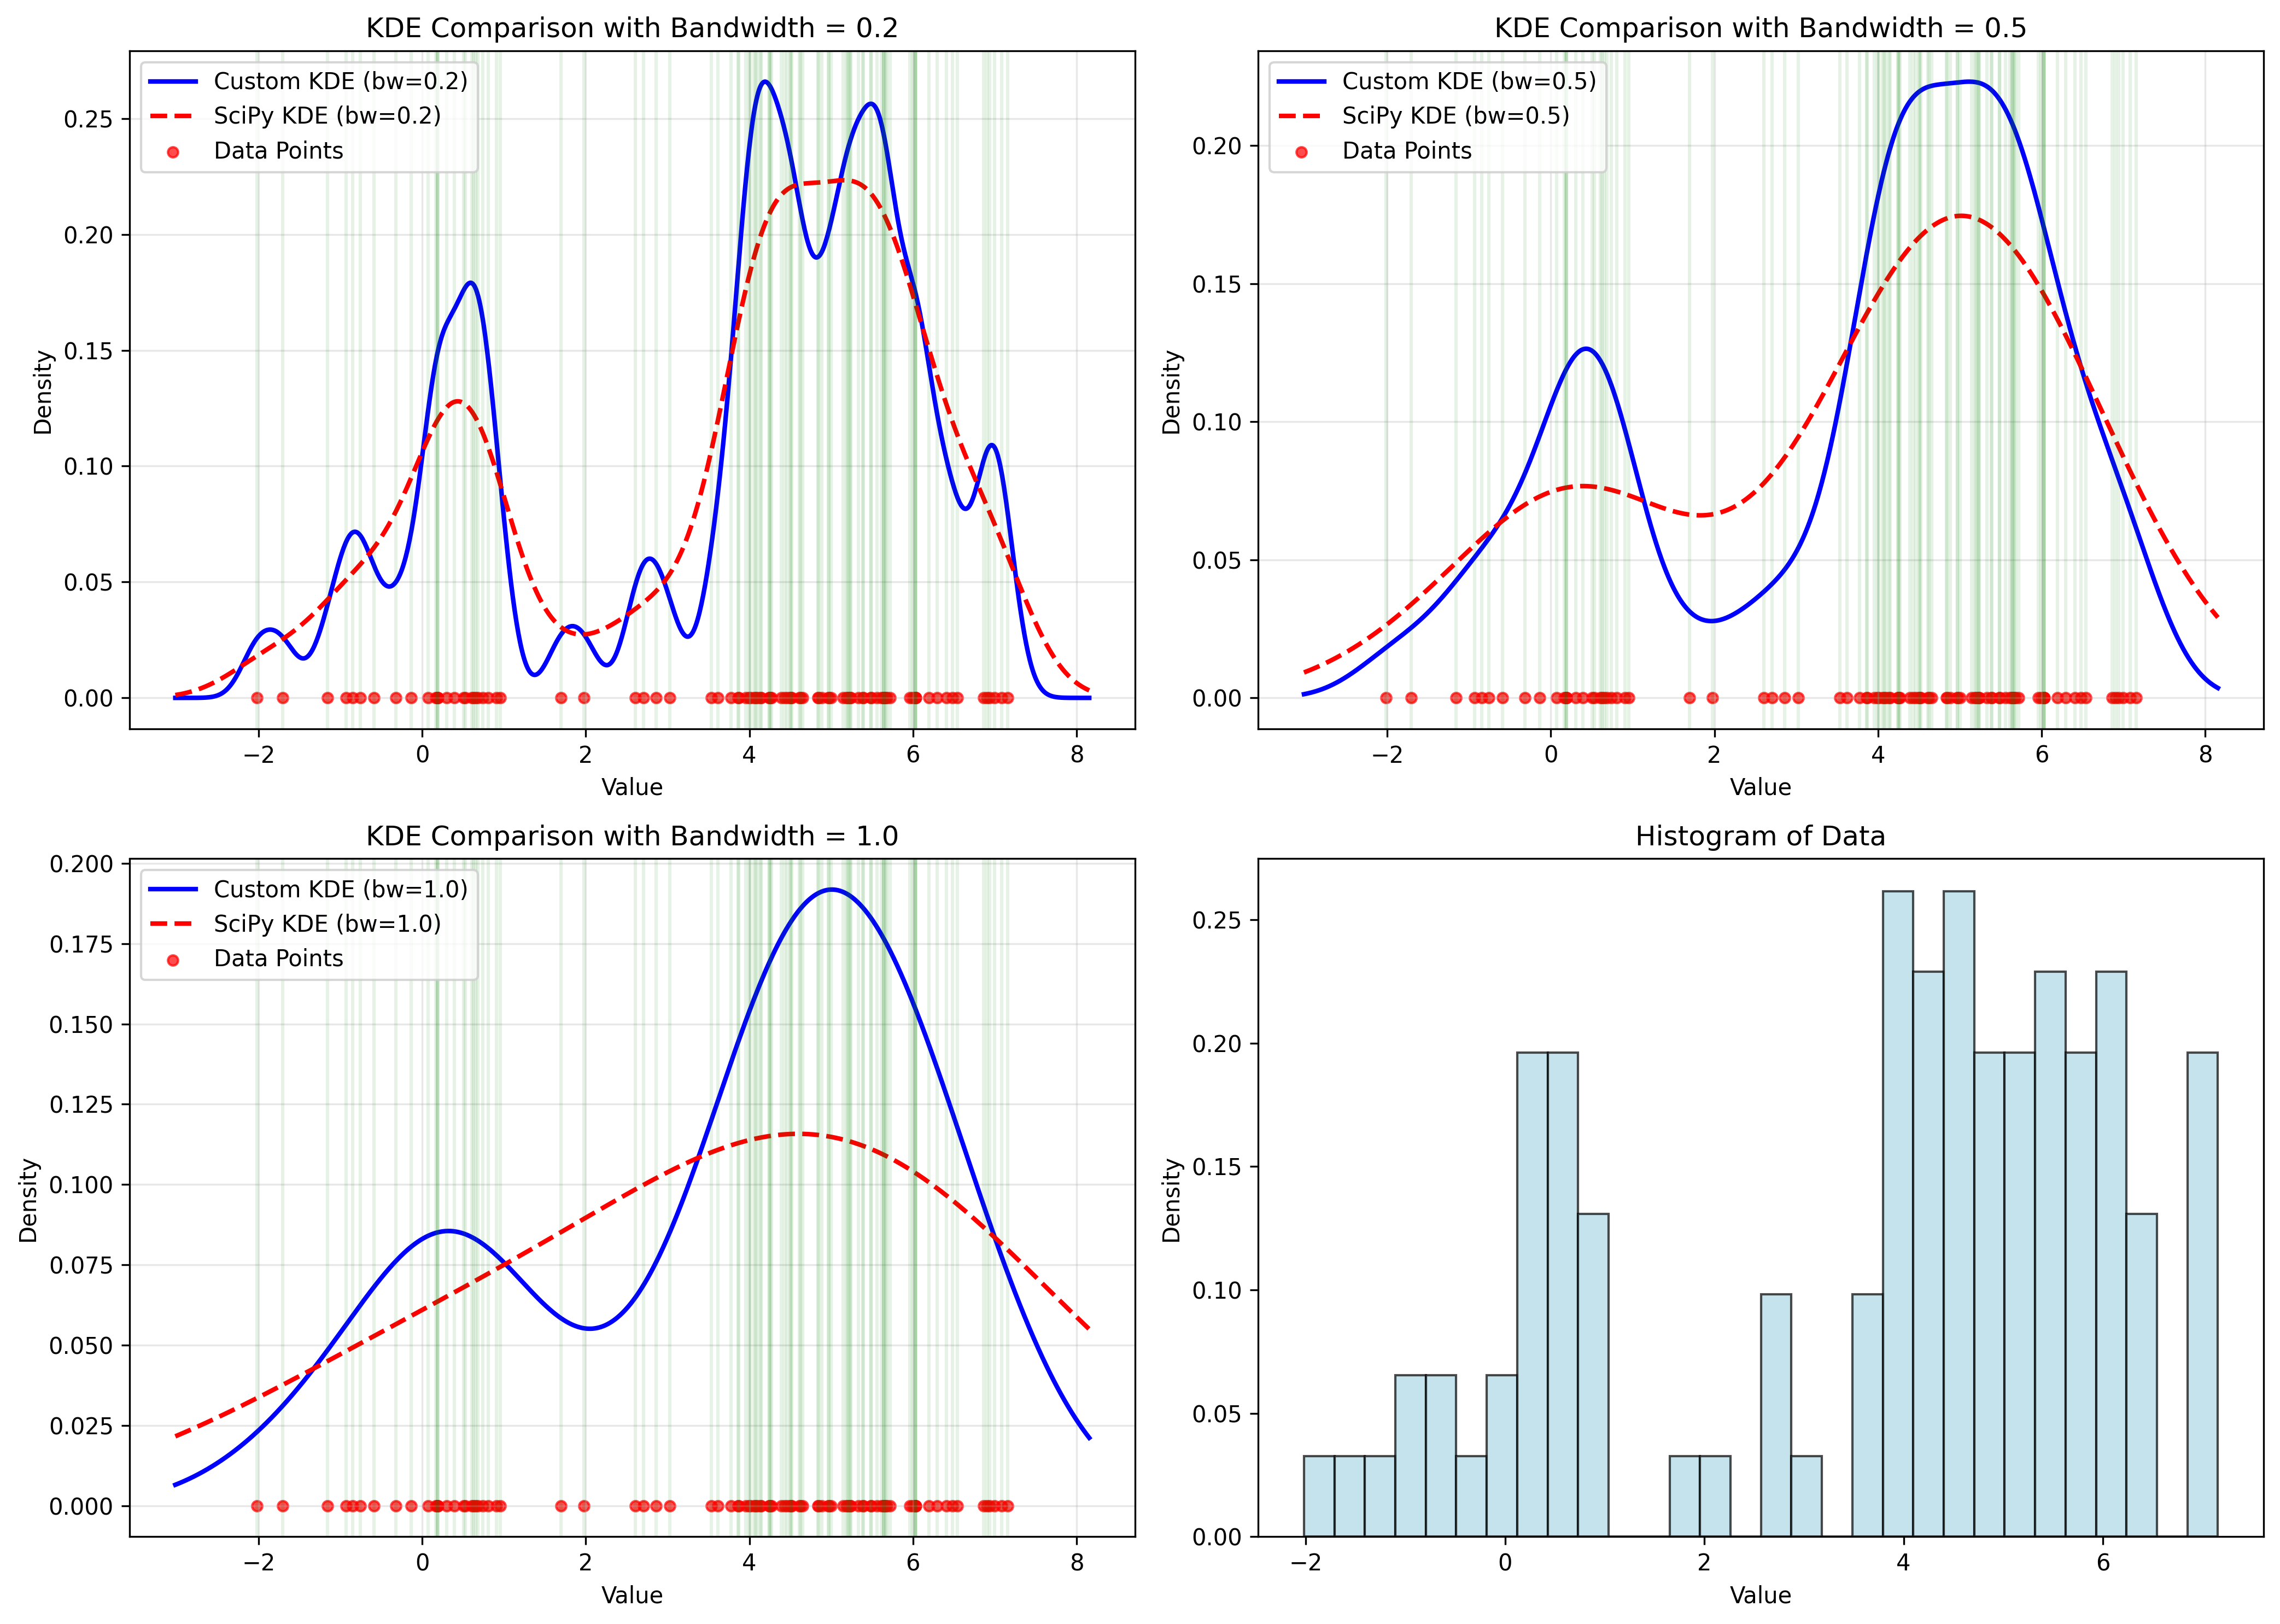

In [38]:
x_range = np.linspace(min(x_medium) - 1, max(x_medium) + 1, 1000)

# Test the custom_kde function on x_medium data
bandwidths = [0.2, 0.5, 1.0]
plt.figure(figsize=(14, 10), dpi=300)

# Plot our custom KDE with different bandwidths
for i, bw in enumerate(bandwidths):
    plt.subplot(2, 2, i+1)
    
    # Calculate KDE using our custom function
    custom_kde_values = custom_kde(x_medium, x_range, bandwidth=bw)
    
    # Plot the custom KDE
    plt.plot(x_range, custom_kde_values, 'b-', linewidth=2, label=f'Custom KDE (bw={bw})')
    
    # Plot the scipy KDE for comparison
    kde_scipy = stats.gaussian_kde(x_medium, bw_method=bw)
    kde_scipy_values = kde_scipy(x_range)
    plt.plot(x_range, kde_scipy_values, 'r--', linewidth=2, label=f'SciPy KDE (bw={bw})')
    
    # Add vertical lines for data points
    for point in x_medium:
        plt.axvline(point, color='green', alpha=0.1)

    plt.scatter(x_medium, np.zeros_like(x_medium), color='red',
                s=20, alpha=0.7, label='Data Points')
    
    plt.title(f'KDE Comparison with Bandwidth = {bw}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)

# Add histogram in the fourth subplot for reference
plt.subplot(2, 2, 4)
plt.hist(x_medium, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black')

# Add individual points for clarity
plt.title('Histogram of Data')
plt.xlabel('Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()